In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [41]:
# Loading data
df = pd.read_csv(r"data\no_show_cleaned.csv")

In [42]:
# Map target variable to readable labels
df['attendance'] = df['no_show'].map({
    0: 'Showed Up',
    1: 'Missed Appointment'
})

# Keep a consistent order across all plots
attendance_order = ["Showed Up", "Missed Appointment"]

In [43]:
# weekday order consistent
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Helper function to add percentages to count plots
def add_percentage_labels(ax, total_count):
    for patch in ax.patches:
        height = patch.get_height()
        percentage = (height / total_count) * 100
        ax.annotate(
            f"{percentage:.1f}%",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10
        )

### Attendance Distribution

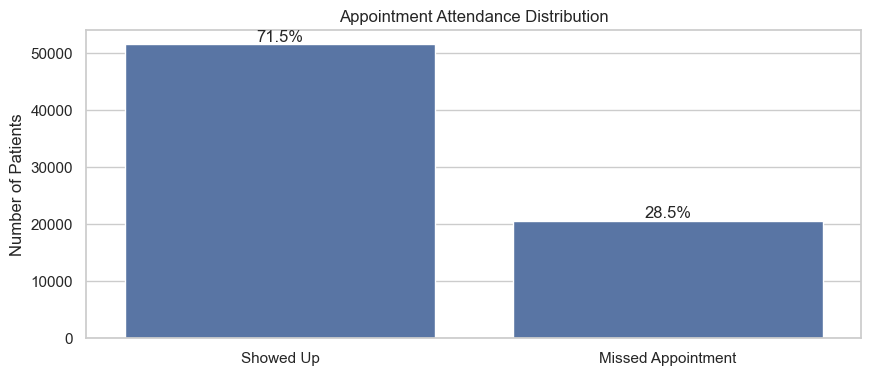

In [44]:
plt.figure(figsize=(10, 4))

ax = sns.countplot(data=df, x='attendance',  order=attendance_order)

# Add percentage labels
total = len(df)
for bar in ax.patches:
    percentage = f"{100 * bar.get_height() / total:.1f}%"
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title("Appointment Attendance Distribution")
plt.xlabel("")
plt.ylabel("Number of Patients")
plt.show()

_Interpretation_

The majority of patients attended their appointments, while a smaller but still substantial proportion missed them. This shows that non-attendance is not the dominant outcome, but it is common enough to create operational challenges.

_Key Insight_

Missed appointments represent a meaningful share of total appointments and justify deeper analysis into the factors influencing patient attendance.

_Business Recommendation_

Healthcare providers should monitor no-show rates regularly and identify high-risk groups early so that resources can be allocated more efficiently.

### Age analysis

##### Age distribution by appointment outcome

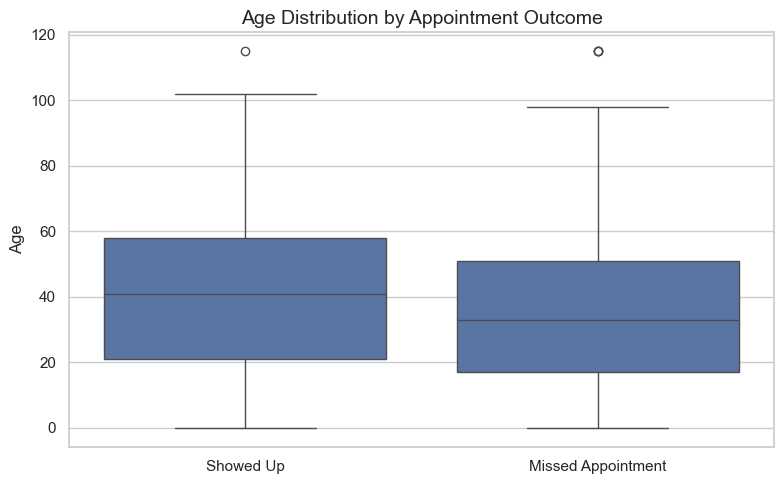

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="attendance",
    y="age",
    order=attendance_order
)

plt.title("Age Distribution by Appointment Outcome", fontsize=14)
plt.xlabel("")
plt.ylabel("Age", fontsize=12)
plt.tight_layout()
plt.show()

_Interpretation_

The plot compares the age distribution of patients who attended appointments versus those who did not show up. There is a noticeable difference in the distribution with missed appointments appearing more concentrated among younger age groups. The median age for no-shows is slightly lower and the spread suggests greater variability among younger patients.

_Key Insight_

Younger patients are more likely to miss appointments compared to older patients, indicating that age may influence attendance behavior.

_Business Recommendation_

Since younger patients have a higher likelihood of missing appointments, clinics could implement targeted interventions such as appointment reminders (SMS/WhatsApp), flexible scheduling or overbooking strategies for this group to reduce no-show rates.

##### No-show rate by age group

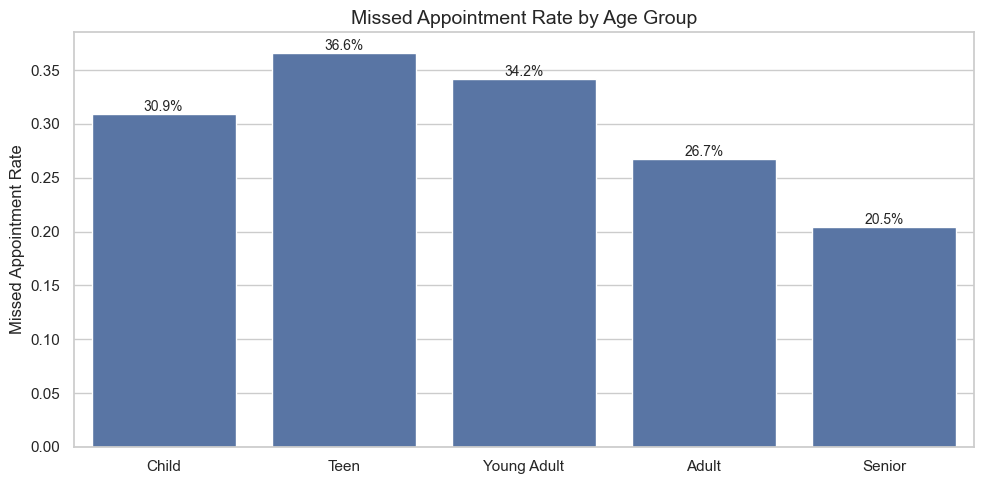

In [46]:
age_group_order = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df,
    x="age_group",
    y="no_show",
    order=age_group_order,
    errorbar=None
)

for bar in ax.patches:
    rate = bar.get_height() * 100
    ax.annotate(
        f"{rate:.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Missed Appointment Rate by Age Group", fontsize=14)
plt.xlabel("")
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.ylim(0, df["no_show"].mean() + 0.1)
plt.tight_layout()
plt.show()

_Interpretation_

This chart shows the proportion of missed appointments within each age group, allowing us to compare no-show rates across different life stages. It highlights how attendance behavior varies by age rather than just overall counts.

_Key Insight_

Younger age groups exhibit a higher proportion of missed appointments compared to older patients, indicating lower appointment adherence among younger individuals.

_Business Recommendation_

Clinics could focus on improving engagement with younger patients by implementing targeted strategies such as automated reminders (SMS/WhatsApp), easy rescheduling options, or digital booking platforms to reduce no-show rates in this group.

### Waiting time analysis

##### Distribution of waiting days


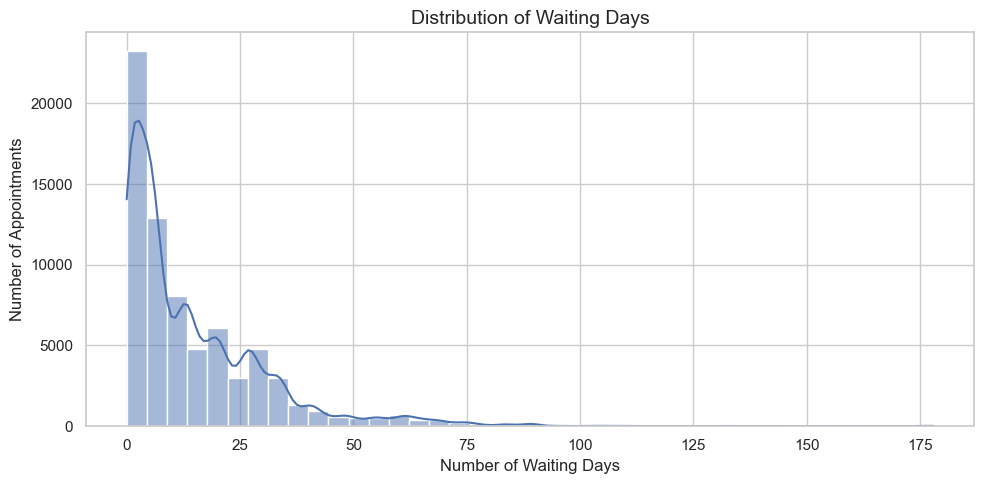

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="waiting_days",
    bins=40,
    kde=True
)

plt.title("Distribution of Waiting Days", fontsize=14)
plt.xlabel("Number of Waiting Days", fontsize=12)
plt.ylabel("Number of Appointments", fontsize=12)
plt.tight_layout()
plt.show()

_Interpretation_ 

The distribution of waiting time is highly skewed with the majority of patients experiencing shorter waiting periods while a smaller proportion face significantly longer delays. This indicates an uneven distribution rather than a uniform spread of waiting times.

_Key Insight_

Most patients are seen within a short time frame but a minority experience long waiting times which could contribute disproportionately to dissatisfaction and missed appointments.

_Business Recommendation_

Healthcare providers should focus on reducing extreme waiting times by optimizing scheduling, managing patient flow, or prioritizing high-delay cases, as even a small number of long waits can negatively impact overall attendance and patient experience.

##### Waiting days by attendance outcome

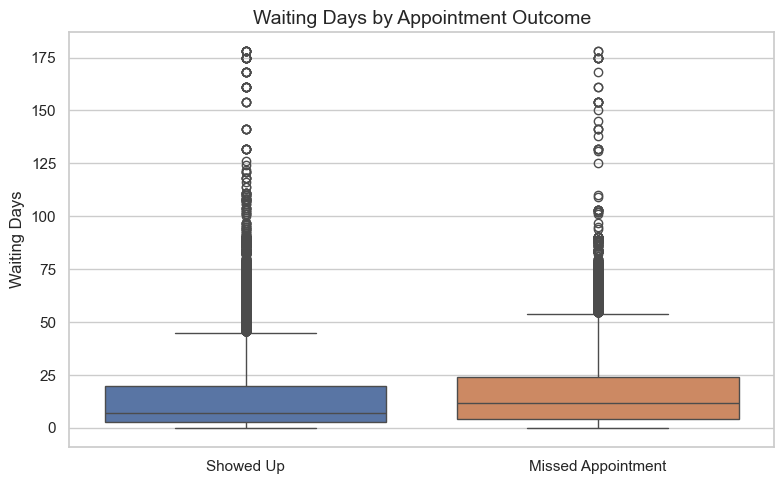

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="attendance",
    y="waiting_days",
    hue="attendance",
    order=attendance_order,
    legend=False
)

plt.title("Waiting Days by Appointment Outcome", fontsize=14)
plt.xlabel("")
plt.ylabel("Waiting Days", fontsize=12)
plt.tight_layout()
plt.show()

_Interpretation_

Patients who missed their appointments generally had longer waiting times compared to those who attended. The median waiting time for missed appointments is higher, indicating a clear relationship between longer delays and non-attendance.

Additionally, the distribution of waiting days among missed appointments is more spread out, suggesting greater variability in how long these patients waited.

_Key Insight_

Longer waiting times are strongly associated with an increased likelihood of missing appointments, making waiting time one of the most influential factors affecting attendance.

_Business Recommendation_

Reducing waiting times could significantly improve appointment attendance rates. Healthcare providers may benefit from optimizing scheduling systems or prioritizing patients with longer waiting periods.

### SMS reminder analysis

##### Missed appointment rate by SMS reminder

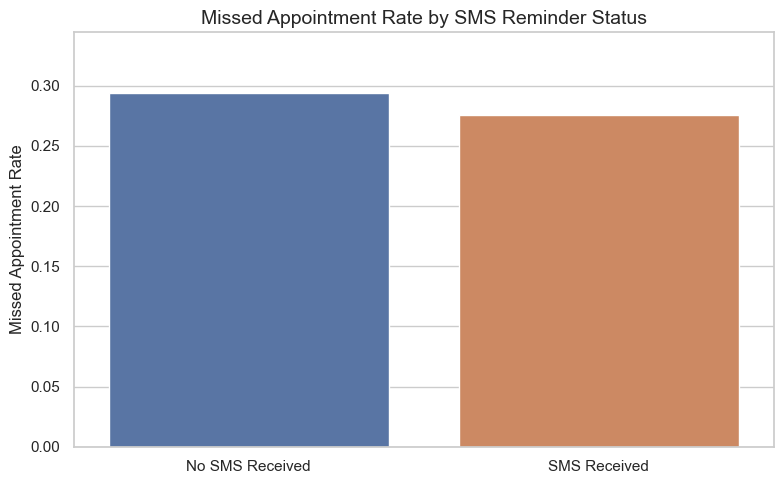

In [52]:
sms_summary = (
    df.groupby("sms_received")["no_show"]
    .mean()
    .reset_index()
)

sms_summary["sms_label"] = sms_summary["sms_received"].map({
    0: "No SMS Received",
    1: "SMS Received"
})

sms_order = ["No SMS Received", "SMS Received"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=sms_summary,
    x="sms_label",
    y="no_show",
    hue="sms_label",
    order=sms_order,
    legend=False
)

plt.title("Missed Appointment Rate by SMS Reminder Status", fontsize=14)
plt.xlabel("")
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.ylim(0, sms_summary["no_show"].max() + 0.05)
plt.tight_layout()
plt.show()

_Interpretation_

The chart compares missed appointment rates between patients who received an SMS reminder and those who did not. Patients who did not receive an SMS show a slightly higher no-show rate compared to those who received reminders.

_Key Insight_

SMS reminders are associated with a small reduction in missed appointments, although the difference is not substantial.

_Business Recommendation_

While SMS reminders appear to have a positive impact, their effect is limited. Clinics could enhance their effectiveness by combining SMS reminders with other strategies such as follow-up calls, personalized messaging or multiple reminder notifications closer to the appointment time.

### Gender analysis

##### Missed appointment rate by gender

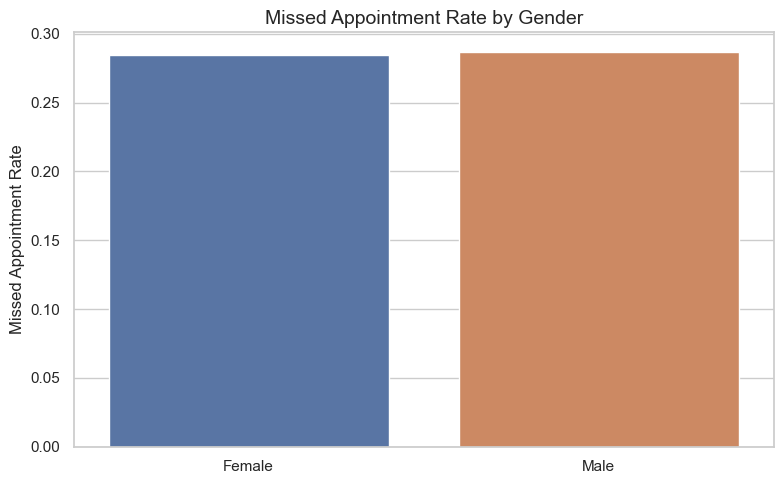

In [55]:
gender_summary = (
    df.groupby("gender")["no_show"]
    .mean()
    .reset_index()
)

# Map values
gender_summary["gender"] = gender_summary["gender"].map({
    "F": "Female",
    "M": "Male"
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_summary,
    x="gender",
    y="no_show",
    hue="gender",
    legend=False
)

plt.title("Missed Appointment Rate by Gender", fontsize=14)
plt.xlabel("")
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.tight_layout()
plt.show()

_Interpretation_

The chart compares missed appointment rates between male and female patients. Both groups exhibit very similar no-show up rates with only a slight difference observed between genders.

_Key Insight_

Gender does not appear to be a strong differentiating factor in predicting missed appointments as both males and females have nearly identical no-show up rates.

_Business Recommendation_

Since gender has minimal impact on appointment attendance, healthcare providers should prioritize other factors (such as waiting time, age or reminder systems) when designing strategies to reduce missed appointments.

### Medical condition analysis

##### Missed appointment rate by hypertension

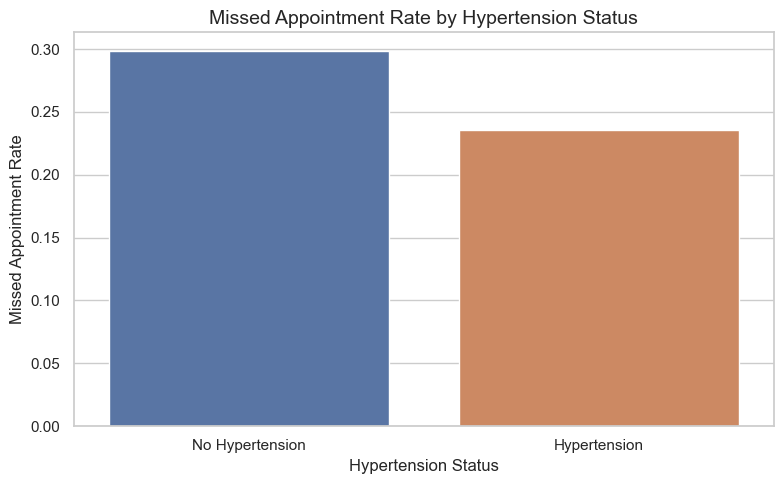

In [56]:
hypertension_summary = (
    df.groupby("hypertension")["no_show"]
    .mean()
    .reset_index()
)

hypertension_summary["hypertension_label"] = hypertension_summary["hypertension"].map({
    0: "No Hypertension",
    1: "Hypertension"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=hypertension_summary,
    x="hypertension_label",
    y="no_show",
    hue="hypertension_label",
    legend=False
)

plt.title("Missed Appointment Rate by Hypertension Status", fontsize=14)
plt.xlabel("Hypertension Status", fontsize=12)
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.tight_layout()
plt.show()

_Interpretation_

Patients without hypertension have a slightly higher missed appointment rate compared to those diagnosed with hypertension.

_Key Insight_

Individuals with hypertension may be more consistent in attending appointments, possibly due to the ongoing need for medical monitoring and treatment.

_Business Recommendation_

Healthcare providers could focus on improving engagement among patients without chronic conditions by reinforcing the importance of regular attendance through reminders or education on preventive care.

##### Missed appointment rate by diabetes

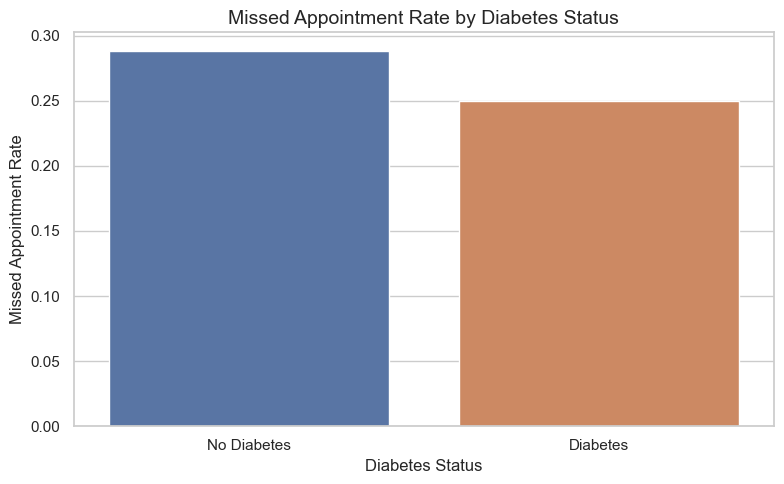

In [57]:
diabetes_summary = (
    df.groupby("diabetes")["no_show"]
    .mean()
    .reset_index()
)

diabetes_summary["diabetes_label"] = diabetes_summary["diabetes"].map({
    0: "No Diabetes",
    1: "Diabetes"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=diabetes_summary,
    x="diabetes_label",
    y="no_show",
    hue="diabetes_label",
    legend=False
)

plt.title("Missed Appointment Rate by Diabetes Status", fontsize=14)
plt.xlabel("Diabetes Status", fontsize=12)
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.tight_layout()
plt.show()

_Interpretation_

Patients without diabetes exhibit a slightly higher missed appointment rate compared to those diagnosed with diabetes.

_Key Insight_

Individuals with diabetes may be more consistent in attending appointments, likely due to the need for ongoing monitoring and management of their condition.

_Business Recommendation_

Healthcare providers should focus on improving attendance among patients without chronic conditions by emphasizing the importance of routine check-ups and implementing reminder systems to reduce no-show rates.

##### Missed appointment rate by alcoholism

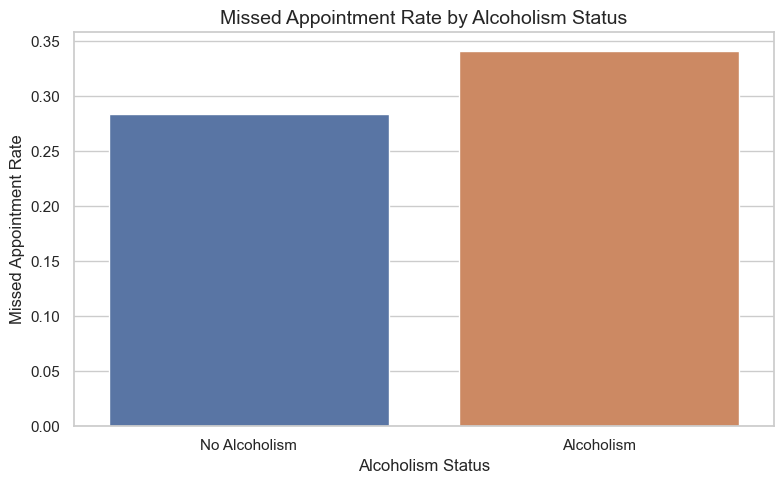

In [58]:
alcoholism_summary = (
    df.groupby("alcoholism")["no_show"]
    .mean()
    .reset_index()
)

alcoholism_summary["alcoholism_label"] = alcoholism_summary["alcoholism"].map({
    0: "No Alcoholism",
    1: "Alcoholism"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=alcoholism_summary,
    x="alcoholism_label",
    y="no_show",
    hue="alcoholism_label",
    legend=False
)

plt.title("Missed Appointment Rate by Alcoholism Status", fontsize=14)
plt.xlabel("Alcoholism Status", fontsize=12)
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.tight_layout()
plt.show()

_Interpretation_

Patients identified as alcoholic have a higher missed appointment rate compared to non-alcoholic patients.

_Key Insight_

Alcohol use may be associated with lower appointment adherence, potentially due to behavioral or lifestyle factors that affect consistency in attending scheduled visits.

_Business Recommendation_

Healthcare providers could implement targeted support strategies for patients with alcohol-related conditions such as enhanced follow-up, personalized reminders or additional counseling to improve attendance rates.

##### Missed appointment rate by handicap level

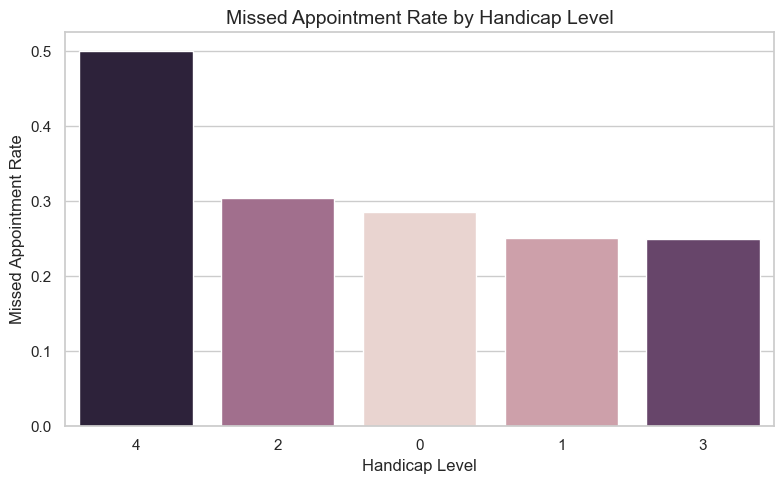

In [62]:
handicap_summary = (
    df.groupby("handicap")["no_show"]
    .mean()
    .reset_index()
)

# Create correct order
order = handicap_summary.sort_values(by="no_show", ascending=False)["handicap"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=handicap_summary,
    x="handicap",
    y="no_show",
    hue="handicap",
    order=order,   # 👈 THIS is the key fix
    legend=False
)

plt.title("Missed Appointment Rate by Handicap Level", fontsize=14)
plt.xlabel("Handicap Level", fontsize=12)
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.tight_layout()
plt.show()

_Interpretation_

The chart shows the missed appointment rate across different handicap (disability count) levels. Most groups (levels 0–3) have relatively similar no-show rates, with only small variations. However, patients at handicap level 4 show a noticeably higher missed appointment rate compared to all other groups.

_Key Insight_

There is no clear trend between increasing handicap levels and missed appointments for most groups, but patients with the highest level of disability (level 4) exhibit a significantly higher no-show rate. This suggests that severe or multiple disabilities may create barriers to attending appointments.

_Business Recommendation_

Healthcare providers should consider providing additional support for patients with higher disability levels, especially those with multiple disabilities. This could include transportation assistance, flexible scheduling, home-based care options, or enhanced reminder systems to improve attendance rates.

_Note_

The higher no-show rate for handicap level 4 may be influenced by a smaller sample size and should be interpreted with caution.

### Scholarship analysis

##### Missed appointment rate by scholarship status

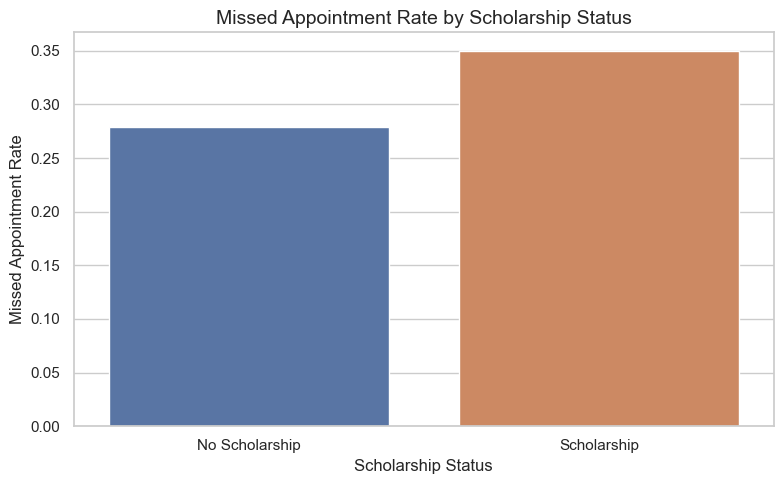

In [63]:
scholarship_summary = (
    df.groupby("scholarship")["no_show"]
    .mean()
    .reset_index()
)

scholarship_summary["scholarship_label"] = scholarship_summary["scholarship"].map({
    0: "No Scholarship",
    1: "Scholarship"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=scholarship_summary,
    x="scholarship_label",
    y="no_show",
    hue="scholarship_label",
    legend=False
)

plt.title("Missed Appointment Rate by Scholarship Status", fontsize=14)
plt.xlabel("Scholarship Status", fontsize=12)
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.tight_layout()
plt.show()

_Interpretation_

Patients who receive a scholarship exhibit a higher missed appointment rate compared to those without a scholarship.

_Key Insight_

This may suggest that patients from lower socioeconomic backgrounds (as indicated by scholarship support) face more barriers to attending appointments such as financial constraints, transportation issues, or competing priorities.

_Business Recommendation_

Healthcare providers should consider targeted interventions for patients on scholarships such as flexible scheduling, transportation support or enhanced reminder systems, to help reduce no-show rates and improve access to care.

### Day-of-week analysis

##### Missed appointment rate by appointment weekday

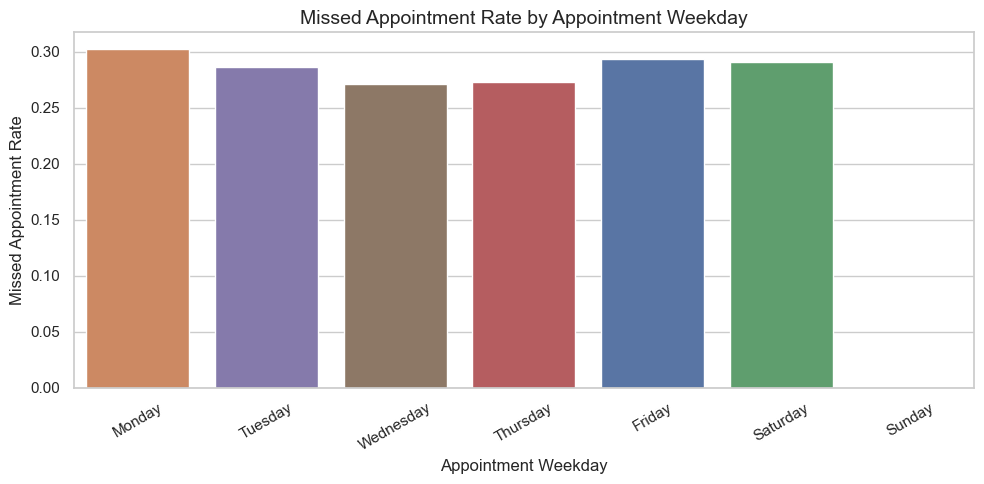

In [64]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_summary = (
    df.groupby("appointment_weekday")["no_show"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_summary,
    x="appointment_weekday",
    y="no_show",
    hue="appointment_weekday",
    order=weekday_order,
    legend=False
)

plt.title("Missed Appointment Rate by Appointment Weekday", fontsize=14)
plt.xlabel("Appointment Weekday", fontsize=12)
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

_Interpretation_

The chart shows the missed appointment rate across different weekdays. The no-show rates are relatively consistent throughout the week, with only slight variations. Monday appears to have a slightly higher missed appointment rate, while midweek days such as Wednesday and Thursday show slightly lower rates.

_Key Insight_

There is no significant variation in missed appointment rates across weekdays, suggesting that the day of the week is not a strong determinant of patient attendance. However, slightly higher no-show rates at the beginning and end of the week may indicate minor behavioral patterns.

_Business Recommendation_

Since weekday differences are minimal, healthcare providers should focus more on other impactful factors (such as waiting time, reminders, and patient demographics). However, slightly higher no-show rates on Mondays could be addressed by reinforcing reminder systems or confirming appointments ahead of the weekend.

_Note_

Absence of Sunday data may indicate that appointments are not scheduled on that day and this should be considered when interpreting the results

##### Missed appointment rate by scheduling weekday

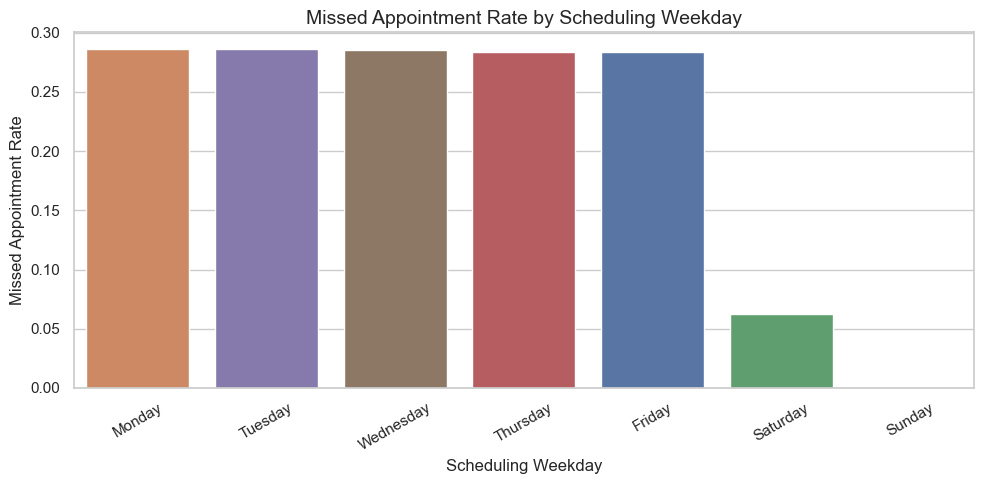

In [65]:
scheduled_weekday_summary = (
    df.groupby("scheduled_weekday")["no_show"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=scheduled_weekday_summary,
    x="scheduled_weekday",
    y="no_show",
    hue="scheduled_weekday",
    order=weekday_order,
    legend=False
)

plt.title("Missed Appointment Rate by Scheduling Weekday", fontsize=14)
plt.xlabel("Scheduling Weekday", fontsize=12)
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

_Interpretation_

The chart shows missed appointment rates based on the day the appointment was scheduled. The no-show rates are fairly consistent for appointments scheduled between Monday and Friday. However, appointments scheduled on Saturday show a significantly lower missed appointment rate compared to all other days.

_Key Insight_

The day on which an appointment is scheduled generally does not impact attendance, except for Saturday, where patients are much more likely to attend. This suggests that scheduling closer to weekends may improve adherence.

_Business Recommendation_

Healthcare providers could consider increasing appointment availability on Saturdays or scheduling more patients closer to the weekend to reduce no-show rates. Additionally, further investigation into why Saturday has a lower no-show rate (e.g. patient availability or fewer competing commitments) could help inform better scheduling strategies.

_Note_

The unusually low no-show rate on Saturday may be influenced by a smaller number of appointments and should be interpreted with caution. Additionally, the absence of Sunday data suggests that appointments are likely not scheduled on that day, which should also be considered when interpreting the results.

### Neighbourhood analysis

##### Top neighbourhoods by missed appointment rate

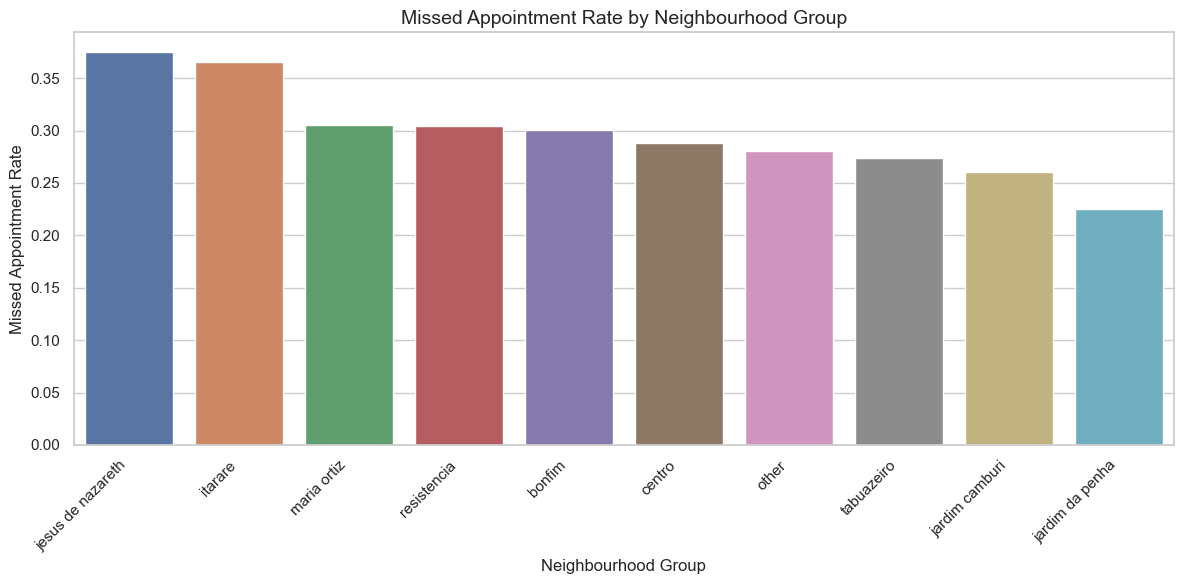

In [66]:
top_neighbourhoods = (
    df["neighbourhood_grouped"]
    .value_counts()
    .head(10)
    .index
)

neighbourhood_summary = (
    df[df["neighbourhood_grouped"].isin(top_neighbourhoods)]
    .groupby("neighbourhood_grouped")["no_show"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=neighbourhood_summary,
    x="neighbourhood_grouped",
    y="no_show",
    hue="neighbourhood_grouped",
    legend=False
)

plt.title("Missed Appointment Rate by Neighbourhood Group", fontsize=14)
plt.xlabel("Neighbourhood Group", fontsize=12)
plt.ylabel("Missed Appointment Rate", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

_Interpretation_

The chart shows the missed appointment rate across different neighbourhood groups. There is noticeable variation in no-show rates between locations. Some neighbourhoods, such as Jesus de Nazareth and Itarare, exhibit higher missed appointment rates while others like Jardim da Penha show relatively lower rates.

_Key Insight_

Geographical location appears to influence appointment attendance, with certain neighbourhoods consistently experiencing higher no-show rates. This suggests that external factors such as accessibility, socioeconomic conditions or distance to healthcare facilities may play a role in patient behavior.

_Business Recommendation_

Healthcare providers should implement location-specific strategies to reduce missed appointments. For neighbourhoods with higher no-show rates, targeted interventions such as transportation support, localized outreach programs, or tailored reminder systems could be effective. Additionally, analyzing underlying factors in high-risk areas can help design more impactful, community-specific solutions.

_Note_
Further analysis could incorporate distance to the clinic or socioeconomic indicators to better understand the observed geographical disparities.

### Correlation among numeric features

##### Correlation heatmap

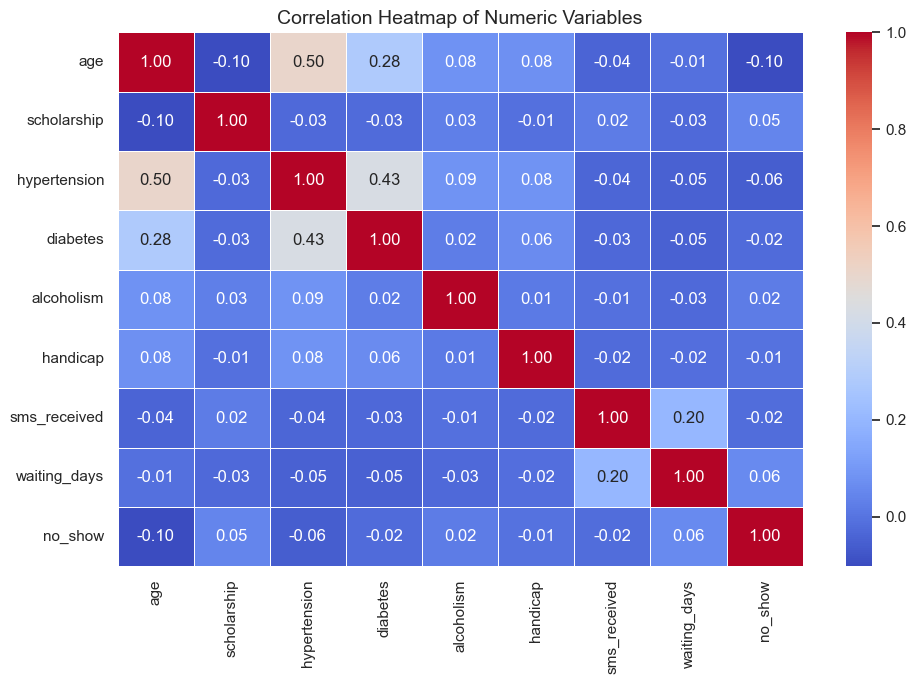

In [68]:
numeric_columns = [
    "age", "scholarship", "hypertension", "diabetes",
    "alcoholism", "handicap", "sms_received",
    "waiting_days", "no_show"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Variables", fontsize=14)
plt.tight_layout()
plt.show()

_Interpretation_

The correlation heatmap shows the relationship between numerical variables and the target variable (no_show). Overall, most variables exhibit very weak correlations with missed appointments, indicating that no single factor strongly explains patient no-show behavior on its own.

_Key Insight_

All features have low correlation values with the target variable, suggesting that missed appointments are influenced by a combination of factors rather than a single dominant variable. Among them:

- Age shows a slight negative relationship (younger patients more likely to miss)
- Waiting days has a small positive relationship (longer waits → more no-shows)
- Other variables (SMS, gender-related proxies, conditions) show minimal linear influence

_Business Recommendation_

Since no single variable strongly predicts no-shows, healthcare providers should adopt a multi-factor approach. Combining factors such as waiting time, age, reminders, and patient history in predictive models or operational strategies will be more effective than relying on any single variable.

## Key EDA Findings
- Waiting time is the strongest factor influencing missed appointments. Patients with longer waiting periods are significantly more likely to miss their appointments.
- Younger patients are more likely to miss appointments compared to older patients, suggesting differences in commitment or availability.
- SMS reminders show mixed effects, possibly due to targeting higher-risk patients rather than effectively reducing no-shows.
- Medical conditions (hypertension, diabetes, alcoholism, handicap) show minimal impact on attendance behavior compared to scheduling-related factors.
- Neighbourhood differences indicate geographic influence, suggesting that location or socioeconomic factors may affect appointment attendance.
- Day of the week has some influence, indicating that scheduling patterns may contribute to missed appointments.
- No single variable strongly explains no-shows, meaning missed appointments are driven by a combination of behavioral and operational factors.



## Final Insight

Missed appointments are primarily driven by operational factors (especially waiting time) and patient behavior, rather than medical conditions. Addressing scheduling delays and identifying high-risk groups can significantly improve attendance rates.

## Business Recommendation

Healthcare providers should:

- Reduce waiting times between scheduling and appointments
- Identify high-risk patients (e.g., long waiting time, younger age groups)
- Improve reminder strategies and timing
- Consider location-based interventions for high-risk neighbourhoods